# Bulk RNA-seq DESeq2 Analysis: Silica Exposure (LUNG)

**Tissue:** LUNG
**Data source:** Plasmidsaurus 3' tag-seq, Illumina platform

---

1. Loads counts matrix and sample metadata
2. Subsets to **LUNG** samples
3. Builds a DESeq2 object
4. QC: PCA, sample-distance heatmap, dispersion plot
6. Produces volcano plots, heatmaps

Note, This notebook calls functions from `pipeline_utils.R`, located in the same directory.

## 1. Setup

In [1]:
.libPaths()
R.version.string

[1] "/nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/R/library"

[1] "R version 4.3.3 (2024-02-29)"

In [2]:
# Core packages
library("DESeq2")
library(tidyverse)
library(pheatmap)
library("RColorBrewer")
library(apeglm)
library(ashr)
library(openxlsx)
library(EnhancedVolcano)
library(ggrepel)

# Load pipeline_utils.R
# see file for description of what each function does
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/pipeline_utils.R")
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/load_featurecounts.R")

# Default plot size
options(repr.plot.width = 10, repr.plot.height = 7)

set.seed(42)
Sys.time()

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

[1] "2026-09-09 16:36:40 EDT"

## 2. Configuration

In [3]:
#----------File paths------------
COUNTS_MATRIX     <- "rawcounts_GRCm39.txt"
GTF_PATH <- "/nfs/roberts/project/pi_epm38/jfd42/GENCODE/GRCm39/gencode.vM39.primary_assembly.annotation.gtf"
METADATA_CSV      <- "metadata.csv"
OUTPUT_DIR        <- "results_lung"
PLOTS_DIR         <- file.path(OUTPUT_DIR, "plots")

#---------Sample selection----------
#Tissue to analyze
TISSUE_FILTER <- "LUNG"

#Exposure groups to analyze
EXPOSURE_GROUPS <- c("CTRL", "Crystalline")

#Sexes to include
SEX_GROUPS <- c("F", "M")

# Option to drop samples (ie: low-quality samples)
# Format: vector of sample_id values that match the metadata sample_id column. ie: c("1", "7")
DROP_SAMPLES <- character(0)  

# ----- Statistical design -----
# DESeq2 design formula
DESIGN_FORMULA <- ~ Sex + Exposure

# Reference levels for each factor
EXPOSURE_REF <- "CTRL"
SEX_REF      <- "F"

# ----- Filtering -----
MIN_COUNT           <- 10
SMALLEST_GROUP_SIZE <- 3

# ----- Significance thresholds -----
PADJ_THRESHOLD <- 0.05
LFC_THRESHOLD  <- 1.5  

# ----- Make output directories -----
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(PLOTS_DIR,  recursive = TRUE, showWarnings = FALSE)

cat("Configuration loaded.\n")
cat("  Tissue:    ", TISSUE_FILTER, "\n")
cat("  Exposures: ", paste(EXPOSURE_GROUPS, collapse = ", "), "\n")
cat("  Sexes:     ", paste(SEX_GROUPS, collapse = ", "), "\n")
cat("  Design:    ", deparse(DESIGN_FORMULA), "\n")
cat("  Output:    ", OUTPUT_DIR, "\n")

Configuration loaded.
  Tissue:     LUNG 
  Exposures:  CTRL, Crystalline 
  Sexes:      F, M 
  Design:     ~Sex + Exposure 
  Output:     results_lung 


## 3. Load expression data and metadata

In [4]:
# Load the raw counts matrix
# Round fractional counts to integers,
# Returns separately a clean counts matrix and gene annotations.
ps <- load_featurecounts(counts_path = COUNTS_MATRIX, gtf_path = GTF_PATH)

counts_full   <- ps$counts
gene_info     <- ps$gene_info
all_sample_ids <- ps$sample_ids

cat("\nFirst 5 sample IDs:\n")
print(head(all_sample_ids, 5))
cat("\nFirst 3 rows of gene_info:\n")
print(head(gene_info, 3))

Reading rawcounts_GRCm39.txt ...
Parsing gene_type from GTF for biotype annotation...
  Biotype assigned for 78045 of 78045 genes
  Genes:   78045 
  Samples: 15 
  Sample names: CTRL_F1, CTRL_F2, CTRL_F4, CTRL_M1, CTRL_M2, CTRL_M3, F1C1, F1C2, F2C2, FAmp_0, FAmp_LL, FAmp_RR, M1C1, M1C2, M1C3 
  Library size range:  2,724,909 to 20,627,481 reads

First 5 sample IDs:
[1] "CTRL_F1" "CTRL_F2" "CTRL_F4" "CTRL_M1" "CTRL_M2"

First 3 rows of gene_info:
        gene_id     gene_name   gene_biotype
1 4933401J01Rik 4933401J01Rik            TEC
2       Gm26206       Gm26206          snRNA
3          Xkr4          Xkr4 protein_coding


In [5]:
# Load metadata
metadata_full <- read.csv(METADATA_CSV, stringsAsFactors = FALSE)

# The sample_id column should match the column names in the counts matrix.

# Convert sample_id from numeric to character
metadata_full$sample_id <- as.character(metadata_full$sample_id)

# Check that all metadata samples exist in counts
missing <- setdiff(metadata_full$sample_id, colnames(counts_full))
if (length(missing) > 0) {
  warning("Metadata samples missing from counts: ",
          paste(missing, collapse = ", "))
}

cat("Metadata loaded.\n")
cat("Total samples in metadata:", nrow(metadata_full), "\n\n")
table(metadata_full$Tissue, metadata_full$Exposure, metadata_full$Sex,
      dnn = c("Tissue", "Exposure", "Sex"))

Metadata loaded.
Total samples in metadata: 15 



, , Sex = F

      Exposure
Tissue Amorphous Crystalline CTRL
  LUNG         3           3    3

, , Sex = M

      Exposure
Tissue Amorphous Crystalline CTRL
  LUNG         0           3    3


## 4. Subset to LUNG samples in selected groups

In [6]:
# Filter metadata according to the config
metadata <- metadata_full %>%
  dplyr::filter(Tissue   == TISSUE_FILTER,
                Exposure %in% EXPOSURE_GROUPS,
                Sex      %in% SEX_GROUPS,
                !sample_id %in% DROP_SAMPLES)

# Convert factor columns and set reference levels
metadata$Exposure <- factor(metadata$Exposure, levels = c(EXPOSURE_REF,
                            setdiff(EXPOSURE_GROUPS, EXPOSURE_REF)))
metadata$Sex      <- factor(metadata$Sex, levels = c(SEX_REF,
                            setdiff(SEX_GROUPS, SEX_REF)))

# Use sample_id as rownames (must match colnames of counts)
rownames(metadata) <- metadata$sample_id

# Subset counts to match
counts <- counts_full[, metadata$sample_id]

cat("After filtering:\n")
cat("  Samples kept:", nrow(metadata), "\n\n")

# Show the design table
cat("Design composition:\n")
print(table(Sex = metadata$Sex, Exposure = metadata$Exposure))

# Sanity: every cell of the design has at least one sample, ideally >= 3
cell_counts <- as.matrix(table(metadata$Sex, metadata$Exposure))
if (any(cell_counts == 0)) {
  warning("Some Sex x Exposure cells have 0 samples - design will fail.")
} else if (any(cell_counts < 3)) {
  warning("Some Sex x Exposure cells have < 3 samples - low power expected.")
}

metadata

After filtering:
  Samples kept: 12 

Design composition:
   Exposure
Sex CTRL Crystalline
  F    3           3
  M    3           3


,sample_id,Sex,Exposure,Tissue,Mouse_ID,Notes
,<chr>,<fct>,<fct>,<chr>,<chr>,<chr>
CTRL_F1,CTRL_F1,F,CTRL,LUNG,FC1,low mapping (~3.1M reads / 79% unique) - watch in QC
CTRL_F2,CTRL_F2,F,CTRL,LUNG,FC2,
CTRL_F4,CTRL_F4,F,CTRL,LUNG,FC4,VERIFY: filename FC4 vs decoding sheet 4FC - same mouse?
CTRL_M1,CTRL_M1,M,CTRL,LUNG,MC1,low mapping (~4.8M reads / 69% unique) - watch in QC
CTRL_M2,CTRL_M2,M,CTRL,LUNG,MC2,
CTRL_M3,CTRL_M3,M,CTRL,LUNG,MC3,
F1C1,F1C1,F,Crystalline,LUNG,F1C1,
F1C2,F1C2,F,Crystalline,LUNG,F1C2,
F2C2,F2C2,F,Crystalline,LUNG,F2C2,


## 5. Fit DESeq2 model

The `build_dds()` helper handles filtering low-count genes, building the DESeq2
object, and running the fit. See `pipeline_utils.R` for what it does exactly.

In [7]:
dds <- build_dds(counts, metadata,
                 design = DESIGN_FORMULA,
                 min_count = MIN_COUNT,
                 smallest_group_size = SMALLEST_GROUP_SIZE)

Building DESeq2 object:
  Samples:         12 
  Initial genes:   78045 
  Design:          ~Sex + Exposure 
  Genes after filter (>= 10 in >= 3 samples): 23692 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Sex_M_vs_F"                  
[3] "Exposure_Crystalline_vs_CTRL"


## 6. Quality control

Check that:
- Size factors are reasonable
- Samples cluster by biology
- The dispersion estimates look like a normal "comet" shape

,Sample,SizeFactor,LibrarySize,Sex,Exposure
,<chr>,<dbl>,<dbl>,<fct>,<fct>
CTRL_F1,CTRL_F1,0.2166255,2707518,F,CTRL
CTRL_F2,CTRL_F2,1.2022109,11120584,F,CTRL
CTRL_F4,CTRL_F4,1.8962334,20107749,F,CTRL
CTRL_M1,CTRL_M1,0.2203936,3007137,M,CTRL
CTRL_M2,CTRL_M2,0.5360317,5988733,M,CTRL
CTRL_M3,CTRL_M3,0.9690980,10478007,M,CTRL
F1C1,F1C1,1.9241809,20422792,F,Crystalline
F1C2,F1C2,1.8787061,20062423,F,Crystalline
F2C2,F2C2,1.7302096,17508200,F,Crystalline


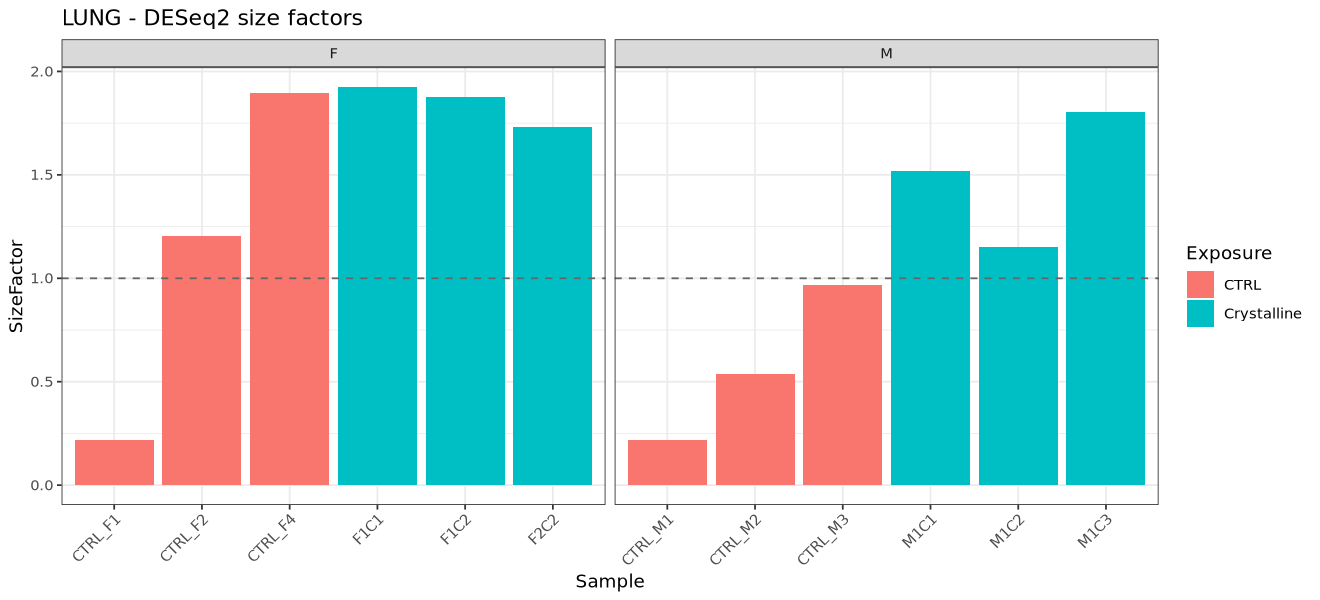

In [8]:
# Size factors per sample
sf_df <- data.frame(
  Sample      = colnames(dds),
  SizeFactor  = sizeFactors(dds),
  LibrarySize = colSums(counts(dds)),
  Sex         = colData(dds)$Sex,
  Exposure    = colData(dds)$Exposure
)

options(repr.plot.width = 11, repr.plot.height = 5)
ggplot(sf_df, aes(x = Sample, y = SizeFactor, fill = Exposure)) +
  geom_col() +
  geom_hline(yintercept = 1, linetype = "dashed", color = "grey40") +
  facet_wrap(~ Sex, scales = "free_x") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = paste(TISSUE_FILTER, "- DESeq2 size factors"))

ggsave(file.path(PLOTS_DIR, "size_factors.pdf"), width = 11, height = 5)
sf_df

In [9]:
# rlog transformation for visualization
rld <- rlogTransformation(dds, blind = FALSE)
cat("rlog-transformed data ready:", dim(assay(rld)), "\n")

rlog-transformed data ready: 23692 12 


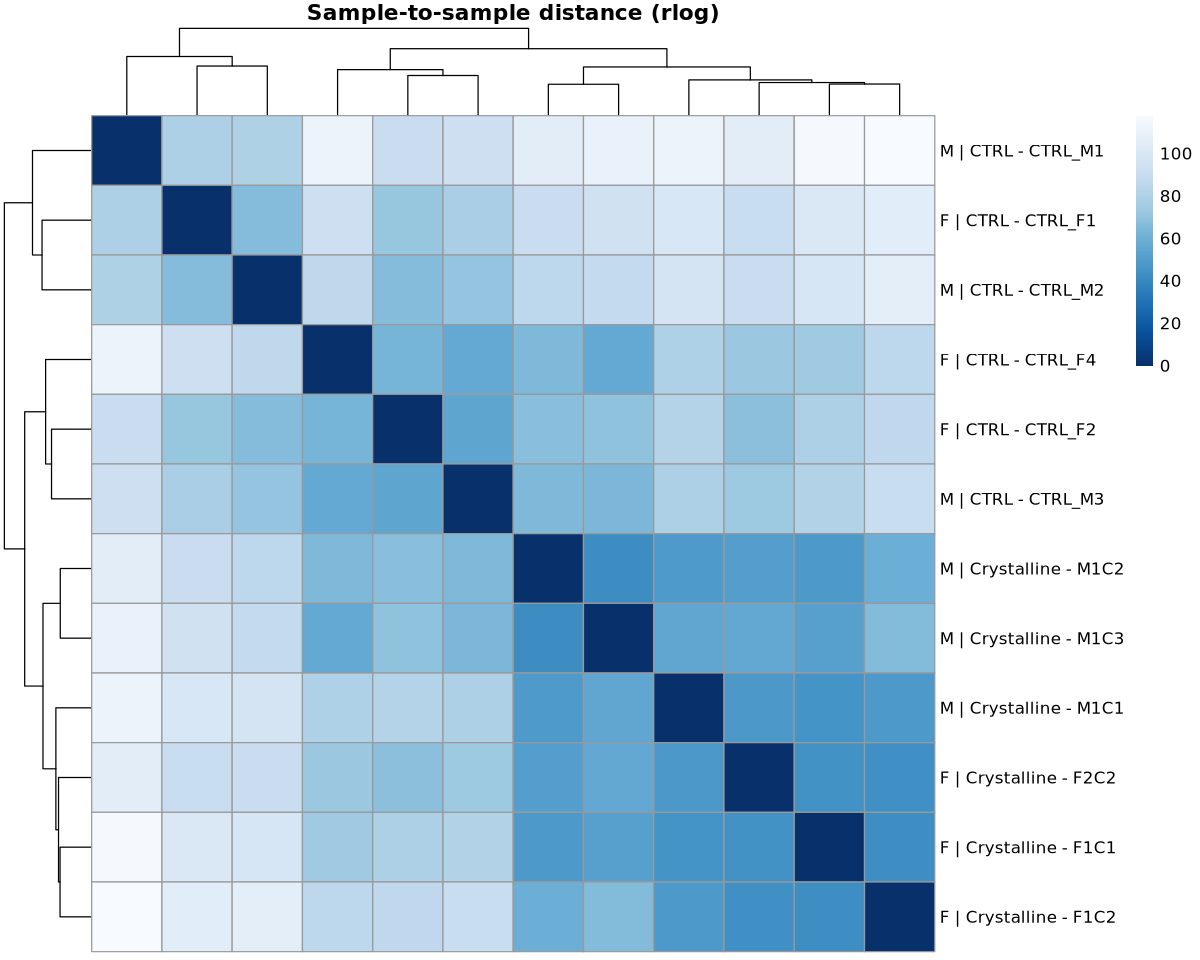

In [10]:
# Sample-distance heatmap
options(repr.plot.width = 10, repr.plot.height = 8)

# Capture the plot object once
ph <- plot_sample_distance(rld, label_cols = c("Sex", "Exposure"))

# Save it to PDF without redrawing
ggplot2::ggsave(
  file.path(PLOTS_DIR, "sample_distance_heatmap.pdf"),
  plot = ph$plot$gtable,
  width = 10, height = 8
)

using ntop=5000 top features by variance



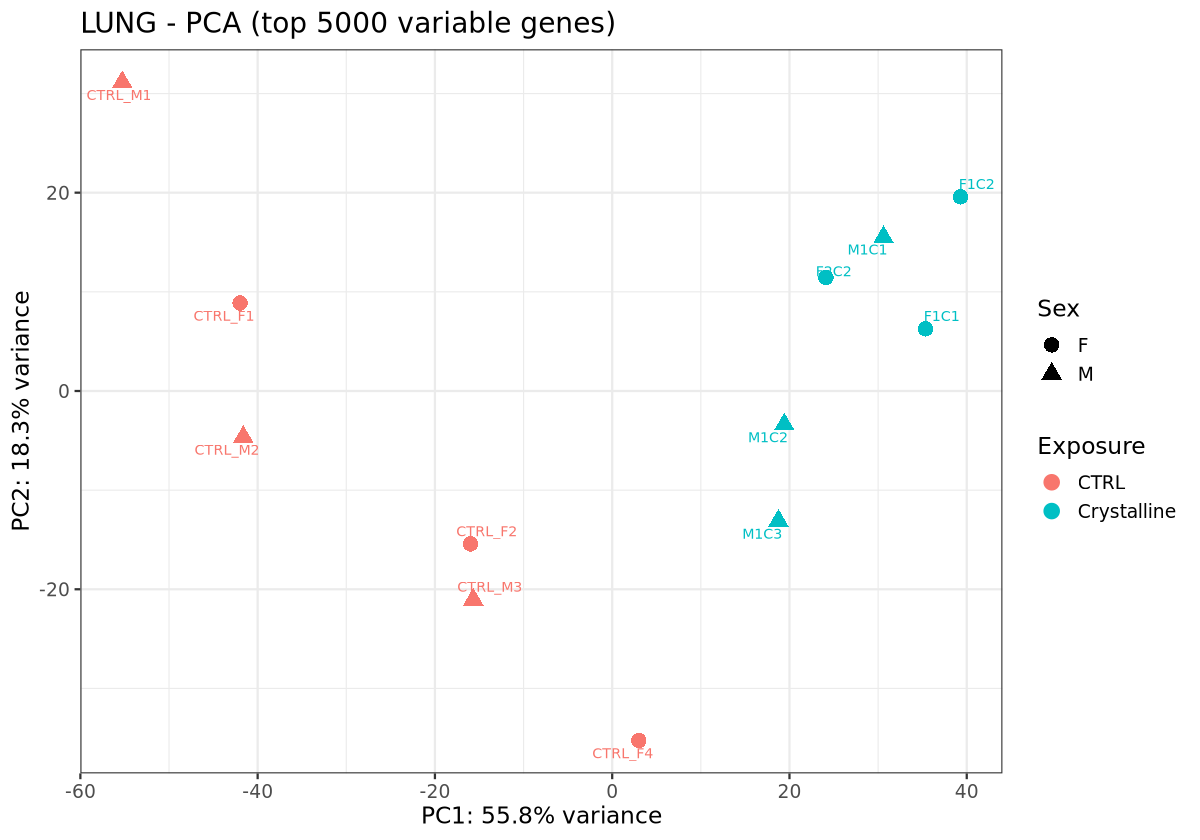

In [11]:
# PCA
options(repr.plot.width = 10, repr.plot.height = 7)
p <- plot_pca_custom(rld, color_by = "Exposure", shape_by = "Sex",
                     ntop = 5000,
                     title = paste(TISSUE_FILTER,
                                   "- PCA (top 5000 variable genes)"))
print(p)
ggsave(file.path(PLOTS_DIR, "PCA_exposure_sex.pdf"), p,
       width = 10, height = 7)

### QC Check of the Principal Components

In [12]:
# Compute full PCA from scratch on the rlog-transformed data
pca <- prcomp(t(assay(rld)))

# Build a data frame of PC scores + metadata
pc_check <- data.frame(
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  Sample = colnames(rld),
  Sex = colData(rld)$Sex,
  Exposure = colData(rld)$Exposure,
  LibrarySize = colSums(counts(dds)),
  SizeFactor = sizeFactors(dds)
)

cat("=== PC1 ===\n")
cat("Correlation with library size: ", round(cor(pc_check$PC1, pc_check$LibrarySize), 3), "\n")
cat("Correlation with size factor:  ", round(cor(pc_check$PC1, pc_check$SizeFactor),  3), "\n")
cat("ANOVA vs Exposure: p =", format.pval(summary(aov(PC1 ~ Exposure, data = pc_check))[[1]][["Pr(>F)"]][1]), "\n")
cat("ANOVA vs Sex:      p =", format.pval(summary(aov(PC1 ~ Sex,      data = pc_check))[[1]][["Pr(>F)"]][1]), "\n\n")

cat("=== PC2 ===\n")
cat("Correlation with library size: ", round(cor(pc_check$PC2, pc_check$LibrarySize), 3), "\n")
cat("ANOVA vs Exposure: p =", format.pval(summary(aov(PC2 ~ Exposure, data = pc_check))[[1]][["Pr(>F)"]][1]), "\n")
cat("ANOVA vs Sex:      p =", format.pval(summary(aov(PC2 ~ Sex,      data = pc_check))[[1]][["Pr(>F)"]][1]), "\n\n")

# Variance explained
var_exp <- round(100 * summary(pca)$importance["Proportion of Variance", 1:5], 1)
cat("=== Variance explained ===\n")
print(var_exp)

=== PC1 ===
Correlation with library size:  0.918 
Correlation with size factor:   0.913 
ANOVA vs Exposure: p = 0.00022501 
ANOVA vs Sex:      p = 0.49776 

=== PC2 ===
Correlation with library size:  -0.196 
ANOVA vs Exposure: p = 0.24755 
ANOVA vs Sex:      p = 0.91491 

=== Variance explained ===
 PC1  PC2  PC3  PC4  PC5 
45.1 17.6  8.6  6.5  5.4 


agg_record_2022809197 
                    2

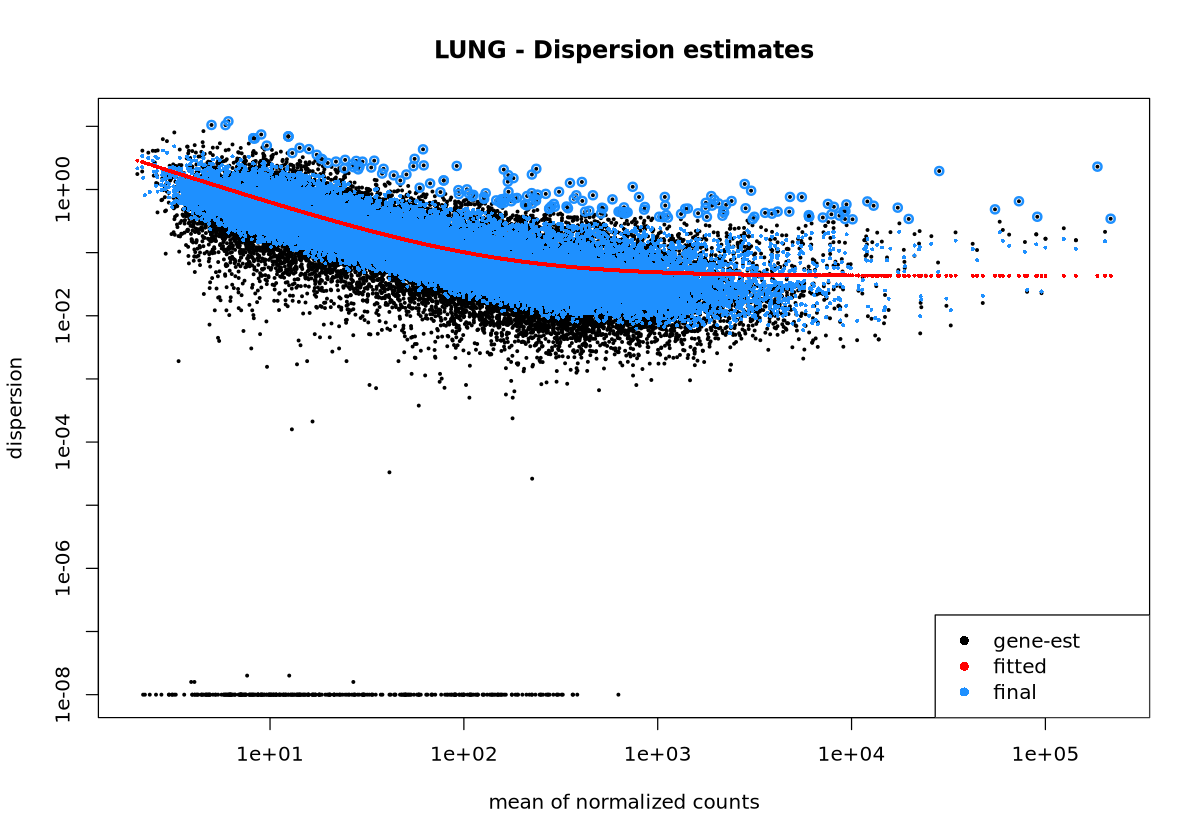

In [13]:
# Dispersion plot - should look like a comet with the red curve fitting nicely
options(repr.plot.width = 10, repr.plot.height = 7)
plotDispEsts(dds, main = paste(TISSUE_FILTER, "- Dispersion estimates"))

pdf(file.path(PLOTS_DIR, "dispersion_plot.pdf"), width = 10, height = 7)
plotDispEsts(dds, main = paste(TISSUE_FILTER, "- Dispersion estimates"))
dev.off()

## 7. Primary contrast: Crystalline vs CTRL

With a `~ Sex + Exposure` design, this contrast tests the **average** effect of
Crystalline exposure vs CTRL, controlling for sex differences. With
`~ Sex + Exposure + Sex:Exposure`, this is the main effect at the reference sex
level (which is harder to interpret on its own — see section 9 for sex-specific
contrasts in interaction models).

In [14]:
# Identify the relevant coefficient name
res_names <- resultsNames(dds)
exposure_coef <- grep("^Exposure_.*_vs_", res_names, value = TRUE)[1]
cat("Using coefficient:", exposure_coef, "\n")

res_exp <- extract_contrast(dds, gene_info, coef = exposure_coef)
head(res_exp, 10)

Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



,gene_id,gene_name,gene_biotype,mean_Crystalline,mean_CTRL,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ly6i,Ly6i,protein_coding,3100.1371,40.56268,1570.3499,6.298052,0.3168608,1.935931e-91,4.578669e-87
2,Lcn2,Lcn2,protein_coding,23771.1190,411.71078,12091.4149,5.784359,0.3457327,3.482912e-65,4.118718e-61
3,Clec7a,Clec7a,protein_coding,2039.7753,149.50645,1094.6409,3.701116,0.2311306,5.048138e-59,3.979784e-55
4,Chi3l1,Chi3l1,protein_coding,17065.2619,2162.87238,9614.0671,2.942827,0.2059895,5.467103e-48,3.232561e-44
5,Wfdc17,Wfdc17,protein_coding,467.9240,21.75737,244.8407,4.408610,0.3102039,4.865891e-47,2.301664e-43
6,Ccl9,Ccl9,protein_coding,2196.1688,104.44122,1150.3050,4.243859,0.3029351,7.347533e-46,2.896275e-42
7,Cd74,Cd74,protein_coding,11491.7500,2904.07061,7197.9103,2.027300,0.1516780,3.841633e-42,1.297978e-38
8,Ltbp2,Ltbp2,protein_coding,719.6628,127.35980,423.5113,2.452441,0.1912420,1.174624e-38,3.472630e-35
9,Mmp12,Mmp12,protein_coding,9480.3339,66.47398,4773.4039,7.035163,0.5800004,1.652102e-36,4.341539e-33


##### Out of interest, wanted to look at the 10 most downregulated genes:

In [15]:
res_exp %>%
  dplyr::filter(!is.na(padj), padj < 0.05) %>%
  dplyr::arrange(log2FoldChange) %>%
  dplyr::slice_head(n = 10) %>%
  dplyr::select(gene_name, gene_biotype, mean_Crystalline, mean_CTRL, log2FoldChange, padj)

gene_name,gene_biotype,mean_Crystalline,mean_CTRL,log2FoldChange,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Gm72996,lncRNA,0.1097903,12.12718,-5.770662,9.020860e-04
Slc22a19,protein_coding,0.2813684,21.23786,-5.428615,8.245862e-06
Or6c217,protein_coding,0.3584912,16.11095,-4.694227,2.730399e-05
Gm47018,lncRNA,0.9321393,36.94860,-4.621488,5.993537e-05
Or4c125,protein_coding,0.2697777,12.61355,-4.596510,2.305580e-04
Vmn1r75,protein_coding,1.7334992,42.30094,-4.589083,1.353257e-05
Gm57889,unprocessed_pseudogene,0.7911241,30.51690,-4.516628,4.565008e-04
Gimd1,protein_coding,0.8443793,29.75363,-4.489112,9.514204e-05
Gm16470,processed_pseudogene,0.4640884,26.66854,-4.445063,6.126667e-05


In [16]:
summarize_significance(res_exp,
                       padj_thresh = PADJ_THRESHOLD,
                       lfc_thresh  = LFC_THRESHOLD)

=== Significance summary ===
Genes tested (non-NA padj): 23651 

padj < 0.05 :
  total:     5803 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     1289 
  upregulated:   532 
  downregulated: 757 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     4186 


Labelling 27 of 23651 genes.


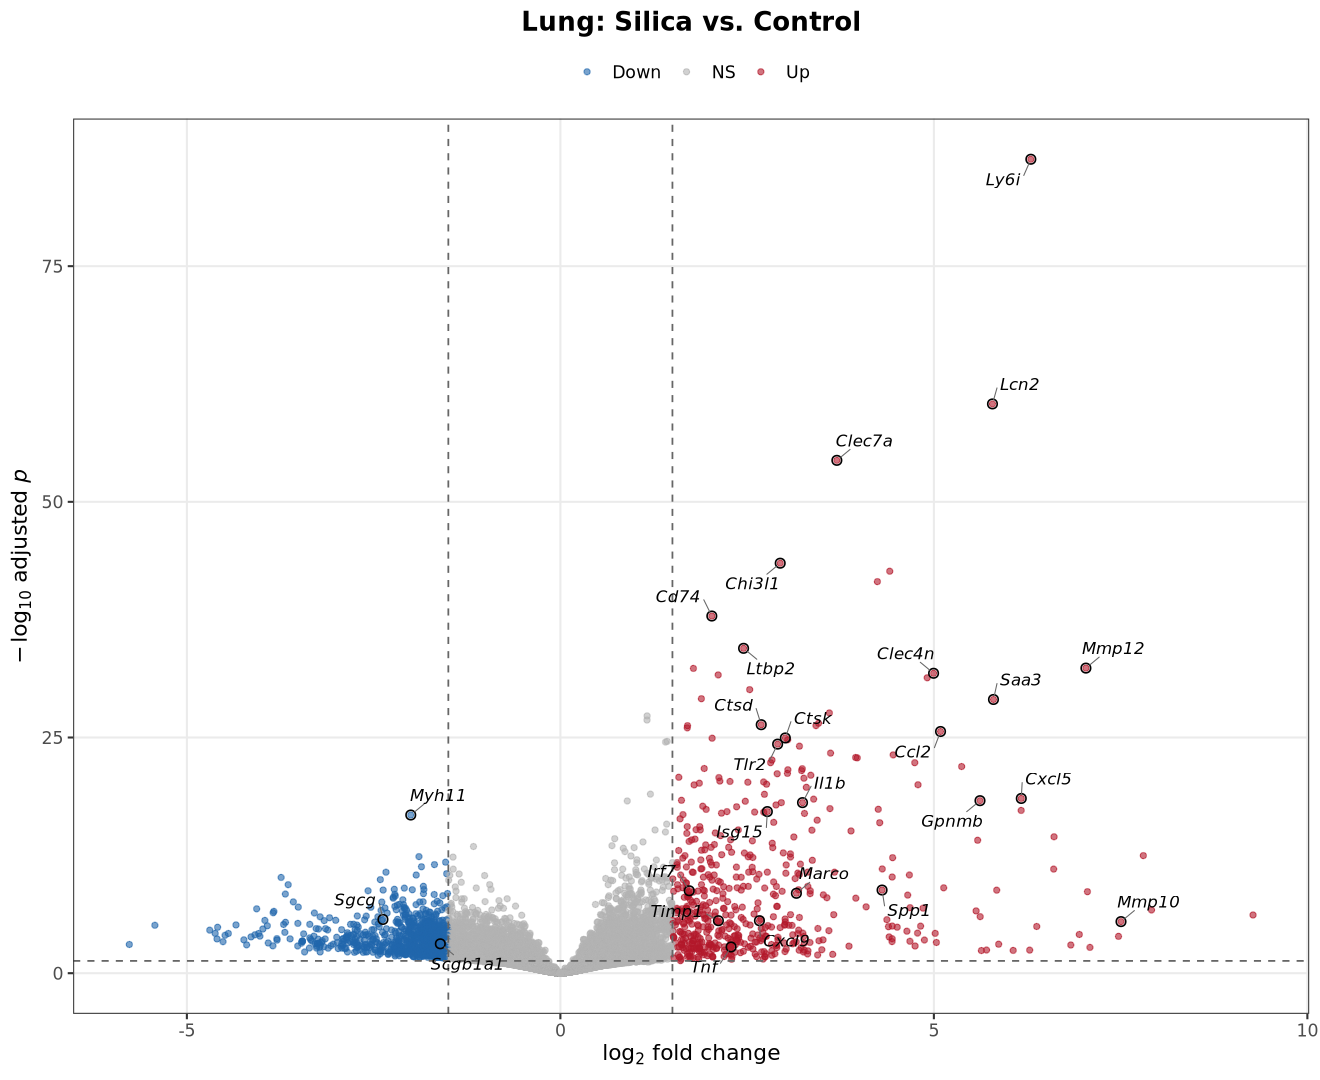

In [17]:
# === Volcano plot with a MANUAL label list ==================================
# Only genes listed in "LABEL_GENES" will pe labelled on the volcano plot.


suppressPackageStartupMessages({
  library(ggplot2)
  library(ggrepel)
  library(dplyr)
})

# ---- Paste your genes here (case-insensitive match on gene symbol) ----------
LABEL_GENES <- c(
  "Ly6i", "Lcn2", "Clec7a", "Chi3l1", "Ccl2", "Cxcl5", "Il1b", "Tlr2", "Cxcl9", 
    "Irf7", "Cd74", "Isg15", "Tnf", "Timp1", "Spp1", "Mmp12", "Mmp10", "Gpnmb", 
    "Marco", "Myh11", "Sgcg", "Scgb1a1", "Ctsk", "Clec4n", "Ctsd", "Saa3", "Ltbp2"
  # ... add / replace with your chosen symbols
)

# ---- Build the plotting data frame from the DESeq2 result -------------------
res_df <- as.data.frame(res_exp)
if (!"gene_name" %in% colnames(res_df)) {
  res_df$gene_name <- rownames(res_df)
}
res_df <- res_df %>% filter(!is.na(padj), !is.na(log2FoldChange))

# Significance category (same thresholds as the config) for colouring.
res_df <- res_df %>%
  mutate(
    sig = case_when(
      padj < PADJ_THRESHOLD & log2FoldChange >=  LFC_THRESHOLD ~ "Up",
      padj < PADJ_THRESHOLD & log2FoldChange <= -LFC_THRESHOLD ~ "Down",
      TRUE ~ "NS"
    ),
    neglog10padj = -log10(padj)
  )

# Which rows get a label: only those whose symbol is in LABEL_GENES.
label_set <- tolower(LABEL_GENES)
res_df$to_label <- tolower(res_df$gene_name) %in% label_set

# Report any requested genes that weren't found / were filtered out.
found <- tolower(res_df$gene_name[res_df$to_label])
missing <- LABEL_GENES[!tolower(LABEL_GENES) %in% found]
if (length(missing) > 0) {
  cat("Note: these LABEL_GENES were not found in the results (check spelling / filtering):\n  ",
      paste(missing, collapse = ", "), "\n")
}
cat("Labelling", sum(res_df$to_label), "of", nrow(res_df), "genes.\n")

# ---- Plot -------------------------------------------------------------------
sig_colors <- c(Up = "#B2182B", Down = "#2166AC", NS = "grey70")

volc <- ggplot(res_df, aes(x = log2FoldChange, y = neglog10padj)) +
  geom_point(aes(color = sig), size = 1.4, alpha = 0.6) +
  scale_color_manual(values = sig_colors, name = NULL) +
  geom_vline(xintercept = c(-LFC_THRESHOLD, LFC_THRESHOLD),
             linetype = "dashed", color = "grey40") +
  geom_hline(yintercept = -log10(PADJ_THRESHOLD),
             linetype = "dashed", color = "grey40") +
  # Emphasise the labelled points, then draw repelled labels for them only.
  geom_point(data = subset(res_df, to_label),
             color = "black", size = 2.2, shape = 21, fill = NA, stroke = 0.7) +
  geom_text_repel(
    data = subset(res_df, to_label),
    aes(label = gene_name),
    size = 3.5,
    fontface = "italic",
    max.overlaps = Inf,
    box.padding = 0.5,
    point.padding = 0.3,
    min.segment.length = 0,
    segment.color = "grey40",
    segment.size = 0.3
  ) +
  labs(x = expression(log[2]~fold~change),
       y = expression(-log[10]~adjusted~italic(p)),
       title = "Lung: Silica vs. Control") +
  theme_bw(base_size = 13) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "top")

options(repr.plot.width = 11, repr.plot.height = 9)
print(volc)

ggsave(file.path(PLOTS_DIR, paste0("volcano_", exposure_coef, "_labeled.pdf")),
       volc, width = 11, height = 9)


In [18]:
# Save outputs (full results, significant only, ranked for GSEA)
write_outputs_for_enrichment(res_exp, OUTPUT_DIR,
                             prefix = paste0(TISSUE_FILTER, "_", exposure_coef),
                             padj_thresh = PADJ_THRESHOLD,
                             lfc_thresh  = LFC_THRESHOLD)

Wrote results_lung/LUNG_Exposure_Crystalline_vs_CTRL_full_results.xlsx ( 23692 genes)
Saved enrichment-ready outputs to results_lung with prefix LUNG_Exposure_Crystalline_vs_CTRL 


## 8. Baseline sex effect (M vs F)

Useful as a sanity check (do you see expected sex-linked genes like Xist, Ddx3y,
Uty?)

In [19]:
sex_coef <- grep("^Sex_.*_vs_", res_names, value = TRUE)[1]

if (length(SEX_GROUPS) >= 2 && !is.na(sex_coef)) {
  cat("Using coefficient:", sex_coef, "\n")
  res_sex <- extract_contrast(dds, gene_info, coef = sex_coef)
  head(res_sex, 10)
} else {
  cat("Only one sex in this analysis - skipping sex contrast.\n")
  res_sex <- NULL
}

Using coefficient: Sex_M_vs_F 
Using coef-based shrinkage (apeglm) for: Sex_M_vs_F 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



,gene_id,gene_name,gene_biotype,mean_M,mean_F,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Tsix,Tsix,lncRNA,117.69822,4.498702e+03,2308.20004,-5.362897,0.2025591,5.876533e-158,1.308998e-153
2,Ddx3y,Ddx3y,protein_coding,959.12592,3.042471e+00,481.08419,8.884522,0.3902960,1.701325e-116,1.894851e-112
3,Xist,Xist,lncRNA,138.28631,5.932842e+03,3035.56427,-5.664250,0.2795077,4.488035e-98,3.332366e-94
4,Eif2s3y,Eif2s3y,protein_coding,435.61792,8.896582e+00,222.25725,5.869428,0.2859107,6.391657e-97,3.559354e-93
5,Uty,Uty,protein_coding,254.82402,1.129385e+00,127.97670,8.663270,0.6689129,8.813760e-41,3.926530e-37
6,Kdm5d,Kdm5d,protein_coding,141.97178,1.356698e+00,71.66424,6.343503,0.5171217,3.754396e-36,1.393820e-32
7,Gm29650,Gm29650,lncRNA,31.71509,0.000000e+00,15.85754,9.781794,2.8115429,3.856870e-17,1.227311e-13
8,Gm4017,Gm4017,processed_pseudogene,42.10241,8.661694e-02,21.09452,7.965903,1.3459798,5.147009e-16,1.433120e-12
9,Spi1,Spi1,protein_coding,137.21200,3.130835e+02,225.14777,-1.226940,0.1915507,5.216880e-12,1.291178e-08


In [20]:
if (!is.null(res_sex)) {
  summarize_significance(res_sex,
                         padj_thresh = PADJ_THRESHOLD,
                         lfc_thresh  = LFC_THRESHOLD)

  # Are the usual sex-linked genes showing up?
  cat("\nClassic sex-linked genes (sanity check):\n")
  sex_markers <- c("Xist", "Ddx3y", "Uty", "Eif2s3y", "Kdm5d", "Tsix")
  print(res_sex %>%
        dplyr::filter(gene_name %in% sex_markers) %>%
        dplyr::select(gene_name, log2FoldChange, padj))
}

=== Significance summary ===
Genes tested (non-NA padj): 22275 

padj < 0.05 :
  total:     226 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     40 
  upregulated:   29 
  downregulated: 11 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     168 

Classic sex-linked genes (sanity check):
  gene_name log2FoldChange          padj
1      Tsix      -5.362897 1.308998e-153
2     Ddx3y       8.884522 1.894851e-112
3      Xist      -5.664250  3.332366e-94
4   Eif2s3y       5.869428  3.559354e-93
5       Uty       8.663270  3.926530e-37
6     Kdm5d       6.343503  1.393820e-32


Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Wrote results_lung/LUNG_Sex_M_vs_F_full_results.xlsx ( 23692 genes)
Saved enrichment-ready outputs to results_lung with prefix LUNG_Sex_M_vs_F 


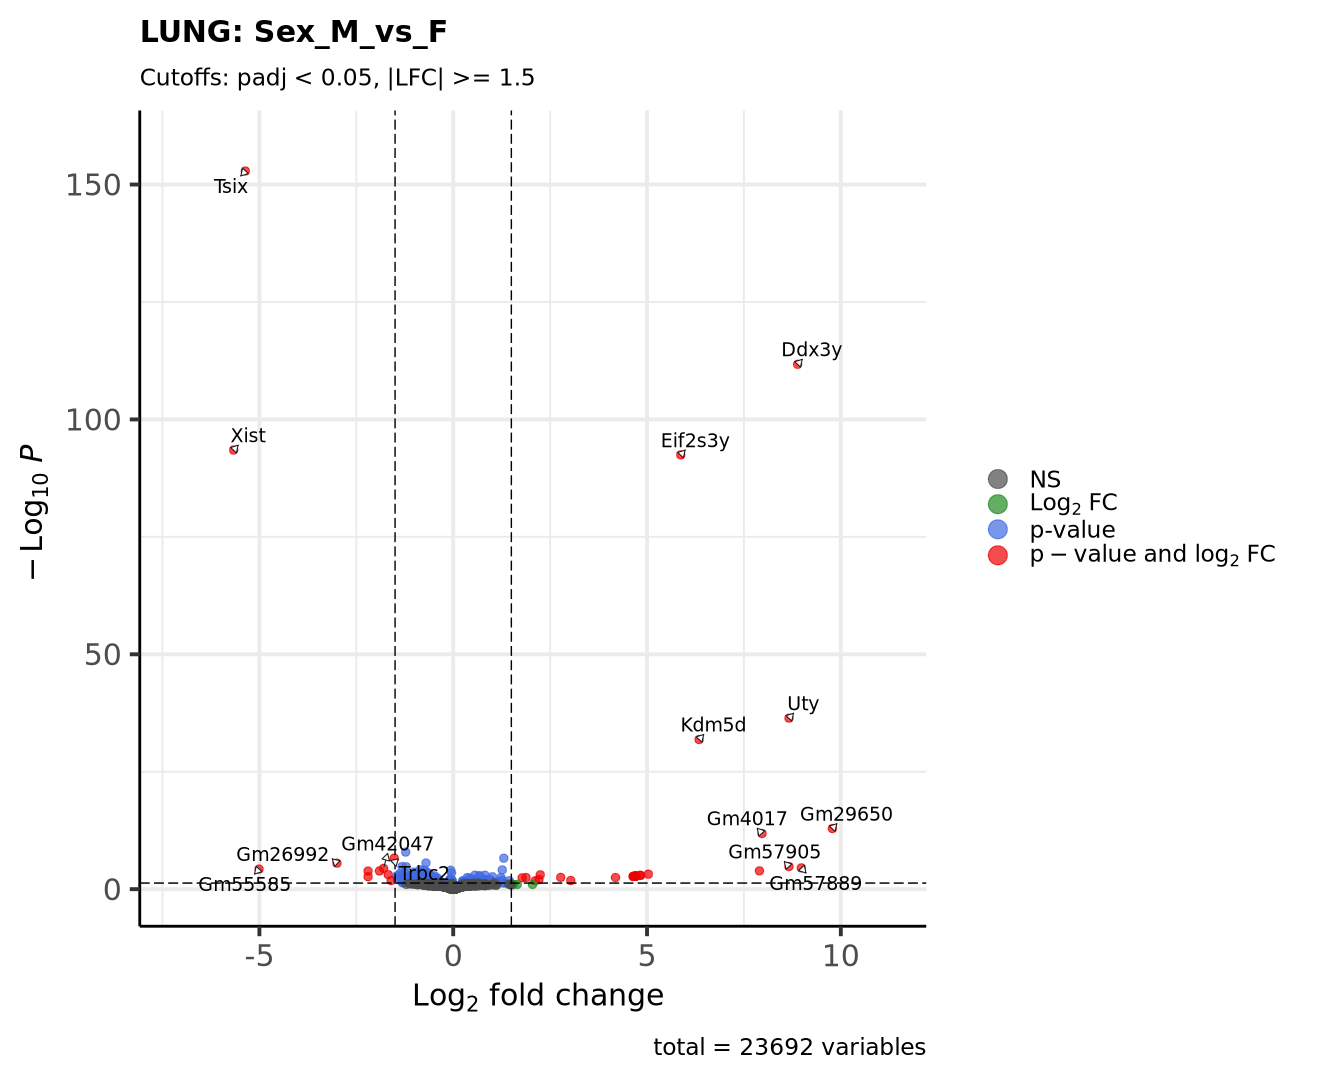

In [21]:
if (!is.null(res_sex)) {
  options(repr.plot.width = 11, repr.plot.height = 9)
  volc_sex <- plot_volcano_custom(res_sex,
                                   padj_thresh = PADJ_THRESHOLD,
                                   lfc_thresh  = LFC_THRESHOLD,
                                   title = paste0(TISSUE_FILTER, ": ", sex_coef))
  print(volc_sex)
  ggsave(file.path(PLOTS_DIR, paste0("volcano_", sex_coef, ".pdf")),
         volc_sex, width = 11, height = 9)

  write_outputs_for_enrichment(res_sex, OUTPUT_DIR,
                               prefix = paste0(TISSUE_FILTER, "_", sex_coef),
                               padj_thresh = PADJ_THRESHOLD,
                               lfc_thresh  = LFC_THRESHOLD)
}

## 9. Sex-specific exposure contrasts

- **Interaction model (`~ Sex + Exposure + Sex:Exposure`):** allows the exposure effect to differ by sex. Per-sex contrasts can then differ. **Requires more samples to be well-powered.

Re-run the exposure contrast, but separated by sex.

In [22]:
# Run the exposure contrast separately within each sex.
# Each subset is fit with ~ Exposure (only one sex present, so no Sex term).

N_TOP <- 50   # how many top DEGs to pull from each per-sex analysis

per_sex_deg <- list()   # will hold the full extract_contrast result per sex

for (this_sex in c("M", "F")) {

  cat("\n=== Exposure contrast, Sex =", this_sex, "===\n")

  # Subset metadata + counts to this sex
  md_sub     <- metadata %>% dplyr::filter(Sex == this_sex)
  counts_sub <- counts[, md_sub$sample_id]

  # Fit DESeq2 within this sex only
  dds_sub <- build_dds(counts_sub, md_sub,
                       design = ~ Exposure,
                       min_count = MIN_COUNT,
                       smallest_group_size = SMALLEST_GROUP_SIZE)

  # Pull the exposure coefficient (e.g. Exposure_Crystalline_vs_CTRL)
  coef_sub <- grep("^Exposure_.*_vs_", resultsNames(dds_sub), value = TRUE)[1]
  cat("Using coefficient:", coef_sub, "\n")

  res_sub <- extract_contrast(dds_sub, gene_info, coef = coef_sub)

  cat("--- Significance summary, Sex =", this_sex, "---\n")
  summarize_significance(res_sub, PADJ_THRESHOLD, LFC_THRESHOLD)

  per_sex_deg[[this_sex]] <- res_sub
}


=== Exposure contrast, Sex = M ===
Building DESeq2 object:
  Samples:         6 
  Initial genes:   78045 
  Design:          ~Exposure 
  Genes after filter (>= 10 in >= 3 samples): 20487 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Exposure_Crystalline_vs_CTRL"
Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



--- Significance summary, Sex = M ---
=== Significance summary ===
Genes tested (non-NA padj): 20084 

padj < 0.05 :
  total:     2496 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     984 
  upregulated:   302 
  downregulated: 682 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     2282 

=== Exposure contrast, Sex = F ===
Building DESeq2 object:
  Samples:         6 
  Initial genes:   78045 
  Design:          ~Exposure 
  Genes after filter (>= 10 in >= 3 samples): 22200 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Exposure_Crystalline_vs_CTRL"
Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



--- Significance summary, Sex = F ---
=== Significance summary ===
Genes tested (non-NA padj): 21331 

padj < 0.05 :
  total:     2343 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     782 
  upregulated:   503 
  downregulated: 279 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     2254 


In [23]:
# Pull the top N DEGs from each per-sex analysis.
# Note that they are ordered simply by p-adj.

top_deg <- lapply(per_sex_deg, function(res) {
  res %>%
    dplyr::filter(!is.na(padj)) %>%
    dplyr::arrange(padj) %>%
    dplyr::slice_head(n = N_TOP) %>%
    dplyr::select(gene_id, gene_name, gene_biotype,
                  log2FoldChange, padj)
})

top_M <- top_deg[["M"]]
top_F <- top_deg[["F"]]

cat("Top", N_TOP, "DEGs (MALES only):\n")
print(top_M)

cat("\nTop", N_TOP, "DEGs (FEMALES only):\n")
print(top_F)

Top 50 DEGs (MALES only):
    gene_id gene_name           gene_biotype log2FoldChange         padj
1      Lcn2      Lcn2         protein_coding       5.330964 1.525382e-43
2      Ly6i      Ly6i         protein_coding       5.938701 2.589036e-29
3      Cd74      Cd74         protein_coding       2.226090 2.007607e-26
4      Saa3      Saa3         protein_coding       4.603191 5.952718e-25
5    S100a9    S100a9         protein_coding       4.008824 1.067663e-24
6    Clec7a    Clec7a         protein_coding       3.422503 6.371249e-22
7    S100a8    S100a8         protein_coding       3.226434 2.791400e-19
8    Chi3l1    Chi3l1         protein_coding       2.590023 4.638245e-19
9   Mir5107   Mir5107                  miRNA       2.384688 8.153640e-19
10  mt-Rnr1   mt-Rnr1                Mt_rRNA      -1.845408 8.215795e-19
11    Fabp5     Fabp5         protein_coding       3.322021 4.219537e-18
12      B2m       B2m         protein_coding       2.155032 1.443516e-17
13   Tyrobp    Tyrobp    

In [25]:
# Rough overlap comparison

side_by_side <- data.frame(
  rank            = seq_len(N_TOP),
  M_gene          = top_M$gene_name,
  M_log2FC        = round(top_M$log2FoldChange, 2),
  M_padj          = signif(top_M$padj, 3),
  F_gene          = top_F$gene_name,
  F_log2FC        = round(top_F$log2FoldChange, 2),
  F_padj          = signif(top_F$padj, 3),
  stringsAsFactors = FALSE
)

cat("Top", N_TOP, "DEGs side by side (ranked by padj within each sex):\n")
print(side_by_side)

# Overlap between the two top-N lists (by gene_id, robust to symbol duplicates)
in_both  <- intersect(top_M$gene_id, top_F$gene_id)
M_only   <- setdiff(top_M$gene_id, top_F$gene_id)
F_only   <- setdiff(top_F$gene_id, top_M$gene_id)

lbl <- function(ids, tbl) {
  g <- tbl$gene_name[match(ids, tbl$gene_id)]
  g[is.na(g) | g == ""] <- ids[is.na(g) | g == ""]
  sort(g)
}

cat("\n=== Overlap of top", N_TOP, "DEG lists ===\n")
cat("In BOTH lists (", length(in_both), "):\n", sep = "")
print(lbl(in_both, top_M))
cat("\nMALES only (", length(M_only), "):\n", sep = "")
print(lbl(M_only, top_M))
cat("\nFEMALES only (", length(F_only), "):\n", sep = "")
print(lbl(F_only, top_F))

Top 50 DEGs side by side (ranked by padj within each sex):
   rank   M_gene M_log2FC   M_padj   F_gene F_log2FC    F_padj
1     1     Lcn2     5.33 1.53e-43     Saa3     7.20 5.42e-113
2     2     Ly6i     5.94 2.59e-29    Mmp12     7.60  6.80e-92
3     3     Cd74     2.23 2.01e-26     Ly6i     6.50  1.77e-88
4     4     Saa3     4.60 5.95e-25     Ccl9     4.58  2.20e-45
5     5   S100a9     4.01 1.07e-24     Lcn2     6.17  1.76e-40
6     6   Clec7a     3.42 6.37e-22   Clec7a     3.89  1.79e-37
7     7   S100a8     3.23 2.79e-19    Gpnmb     6.09  1.30e-35
8     8   Chi3l1     2.59 4.64e-19   Chi3l1     3.23  1.95e-32
9     9  Mir5107     2.38 8.15e-19     Ccl3     6.42  4.64e-32
10   10  mt-Rnr1    -1.85 8.22e-19     Ctsk     3.58  9.52e-31
11   11    Fabp5     3.32 4.22e-18     Igkc     3.50  5.58e-30
12   12      B2m     2.16 1.44e-17  Gm68839     3.50  5.58e-30
13   13   Tyrobp     2.95 9.72e-17   Wfdc17     4.37  5.58e-30
14   14     Ccl9     3.80 1.27e-15     Ccl2     6.03  2.43e

In [26]:
# Save the per-sex top-N lists and the side-by-side comparison for manual review.

write.csv(top_M,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_males.csv")),
          row.names = FALSE)
write.csv(top_F,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_females.csv")),
          row.names = FALSE)
write.csv(side_by_side,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_M_vs_F_sidebyside.csv")),
          row.names = FALSE)

# Also drop them into a single multi-sheet workbook
wb <- createWorkbook()
addWorksheet(wb, "top_males");       writeData(wb, "top_males",       top_M)
addWorksheet(wb, "top_females");     writeData(wb, "top_females",     top_F)
addWorksheet(wb, "side_by_side");    writeData(wb, "side_by_side",    side_by_side)
saveWorkbook(wb,
             file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_by_sex.xlsx")),
             overwrite = TRUE)

cat("Saved per-sex top-", N_TOP, " DEG lists and side-by-side comparison to ",
    OUTPUT_DIR, "\n", sep = "")

Saved per-sex top-50 DEG lists and side-by-side comparison to results_lung


## Save normalized counts and DESeq2 objects

In [27]:
# Normalized counts (useful for plotting individual genes)
norm_counts <- counts(dds, normalized = TRUE) %>%
  as.data.frame() %>%
  tibble::rownames_to_column("gene_id") %>%
  dplyr::left_join(gene_info, by = "gene_id") %>%
  dplyr::relocate(gene_id, gene_name, gene_biotype)

write.csv(norm_counts,
          file.path(OUTPUT_DIR, "normalized_counts.csv"),
          row.names = FALSE)
write.xlsx(norm_counts,
           file.path(OUTPUT_DIR, "normalized_counts.xlsx"),
           asTable = TRUE,
           tableStyle = "TableStyleMedium2",
           firstRow = TRUE)

cat("Saved normalized counts (",
    nrow(norm_counts), "genes x", ncol(norm_counts), "cols)\n")

Saved normalized counts ( 23692 genes x 15 cols)


In [28]:
# Save DESeq2 objects so you can reload without re-running
saveRDS(dds, file.path(OUTPUT_DIR, "dds.rds"))
saveRDS(rld, file.path(OUTPUT_DIR, "rld.rds"))
cat("Saved DESeq2 objects.\n")
cat("Reload later with:\n")
cat("  dds <- readRDS('", file.path(OUTPUT_DIR, "dds.rds"), "')\n", sep = "")
cat("  rld <- readRDS('", file.path(OUTPUT_DIR, "rld.rds"), "')\n", sep = "")

Saved DESeq2 objects.
Reload later with:
  dds <- readRDS('results_lung/dds.rds')
  rld <- readRDS('results_lung/rld.rds')


## 13. Session info

In [29]:
sessionInfo()
capture.output(sessionInfo(), file = file.path(OUTPUT_DIR, "sessionInfo.txt"))
Sys.time()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.6 (Plow)

Matrix products: default
BLAS/LAPACK: /nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] EnhancedVolcano_1.20.0      ggrepel_0.9.6              
 [3] openxlsx_4.2.8              ashr_2.2-63                
 [5] apeglm_1.24.0               RColorBrewer_1.1-3         
 [7] pheatmap_1.0.13          

[1] "2026-09-09 17:07:47 EDT"

In [30]:
for (p in c("DESeq2","apeglm","ashr","clusterProfiler","msigdbr","enrichplot","Rsubread","edgeR")) {
  v <- tryCatch(as.character(packageVersion(p)), error = function(e) "not installed")
  cat(sprintf("%-18s %s\n", p, v))
}
R.version.string

DESeq2             1.42.0
apeglm             1.24.0
ashr               2.2.63
clusterProfiler    4.10.0
msigdbr            25.1.1
enrichplot         1.22.0
Rsubread           not installed
edgeR              not installed


[1] "R version 4.3.3 (2024-02-29)"